# День 5 — Error analysis и интерпретация результатов

**Цель:** не ограничиваться итоговым значением метрики, а понять, какие классы и формулировки вызывают ошибки лучшей модели. Ноутбук полностью автономен: он скачивает исходные данные, повторяет preprocessing, создаёт split и обучает зафиксированного победителя дня 4 с нуля.

## Почему это честный анализ

Параметры модели уже были выбраны cross-validation на train-части в день 4. Здесь мы не подбираем модель и не изменяем её по результатам test set. Test используется один раз для диагностики: любые идеи улучшения из этого ноутбука должны позднее проверяться на новой validation-схеме, а не на этом же test set.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from finnews_sentiment.data.load_data import DEFAULT_CONFIG, load_financial_phrasebank
from finnews_sentiment.features.preprocess import EXPECTED_SENTIMENTS, prepare_news_data
from finnews_sentiment.models.error_analysis import (
    analyze_predictions,
    plot_confusion_matrices,
    save_error_analysis_artifacts,
    split_for_error_analysis,
)
from finnews_sentiment.models.train_improved import build_day4_winner_pipeline

## 1. Конфигурация и выходные файлы

Используем те же `test_size=0.2` и `random_state=42`, что в днях 3–4. Ни локальный CSV, ни сохранённая модель, ни предыдущие отчёты не являются входом этого ноутбука.

In [2]:
current_dir = Path.cwd().resolve()
PROJECT_ROOT = current_dir if (current_dir / 'pyproject.toml').exists() else current_dir.parent
assert (PROJECT_ROOT / 'pyproject.toml').exists(), 'Запустите ноутбук из корня проекта или папки notebooks'

REPORT_DIR = PROJECT_ROOT / 'reports/day05'
TEST_SIZE = 0.2
RANDOM_STATE = 42
print(f'Отчёты будут сохранены в: {REPORT_DIR.relative_to(PROJECT_ROOT)}')

Отчёты будут сохранены в: reports/day05


## 2. Загрузка и preprocessing с нуля

Берём конфигурацию Financial PhraseBank `sentences_75agree`. Общий preprocessing нормализует регистр и пробелы, сохраняет финансовые числа и символы, удаляет пустые строки и точные дубли, а также проверяет классы. При первом запуске исходный архив скачивается с Hugging Face.

In [3]:
raw_df = load_financial_phrasebank(DEFAULT_CONFIG)
df = prepare_news_data(raw_df)

assert len(df) == 3448
assert df['text_clean'].ne('').all()
assert set(df['sentiment']) == set(EXPECTED_SENTIMENTS)
assert not df.duplicated(['text_clean', 'sentiment']).any()
print(f'Исходных строк: {len(raw_df)}')
print(f'После preprocessing: {len(df)}')
display(df[['text', 'text_clean', 'sentiment']].head())

Исходных строк: 3453
После preprocessing: 3448


,text,text_clean,sentiment
0,"According to Gran , the company has no plans t...","according to gran , the company has no plans t...",neutral
1,With the new production plant the company woul...,with the new production plant the company woul...,positive
2,"For the last quarter of 2010 , Componenta 's n...","for the last quarter of 2010 , componenta 's n...",positive
3,"In the third quarter of 2010 , net sales incre...","in the third quarter of 2010 , net sales incre...",positive
4,Operating profit rose to EUR 13.1 mn from EUR ...,operating profit rose to eur 13.1 mn from eur ...,positive


## 3. Воспроизводимый train/test split

Стратификация сохраняет доли трёх классов. TF-IDF ещё не обучен: это принципиально важно, потому что словарь и веса признаков должны видеть только train-часть. `source_index` позволит связать каждую ошибку с подготовленной строкой.

In [4]:
train_df, test_df = split_for_error_analysis(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
split_distribution = pd.DataFrame({
    'train': train_df['sentiment'].value_counts(),
    'test': test_df['sentiment'].value_counts(),
}).reindex(EXPECTED_SENTIMENTS)
display(split_distribution)
assert len(train_df) == 2758
assert len(test_df) == 690
assert split_distribution['test'].to_dict() == {'negative': 84, 'neutral': 428, 'positive': 178}

,train,test
sentiment,,
negative,336,84
neutral,1713,428
positive,709,178


## 4. Обучение победителя дня 4 с нуля

Повторяем не GridSearch, а уже выбранную конфигурацию: unigram TF-IDF с `min_df=2`, `sublinear_tf=True` и LinearSVC с `C=0.5`, `class_weight='balanced'`. Pipeline обучает TF-IDF и классификатор исключительно на 2758 train-примерах.

In [5]:
model = build_day4_winner_pipeline(random_state=RANDOM_STATE)
model.fit(train_df['text_clean'], train_df['sentiment'])
display(pd.Series({
    'model': type(model.named_steps['clf']).__name__,
    'C': model.named_steps['clf'].C,
    'class_weight': model.named_steps['clf'].class_weight,
    'max_features': model.named_steps['tfidf'].max_features,
    'min_df': model.named_steps['tfidf'].min_df,
    'ngram_range': model.named_steps['tfidf'].ngram_range,
    'sublinear_tf': model.named_steps['tfidf'].sublinear_tf,
}, name='Значение').to_frame())

,Значение
model,LinearSVC
C,0.5
class_weight,balanced
max_features,5000
min_df,2
ngram_range,"(1, 1)"
sublinear_tf,True


## 5. Метрики и проверка воспроизводимости

Accuracy показывает долю всех правильных ответов, но при преобладании `neutral` может выглядеть лучше реального качества редких классов. Поэтому основной показатель — **macro F1**: сначала F1 считается отдельно для каждого класса, затем три значения усредняются с одинаковым весом. Weighted F1, напротив, сильнее зависит от большого нейтрального класса.

In [6]:
predictions, confusion_counts, confusion_normalized, summary = analyze_predictions(
    model, test_df
)
summary['split'] = {
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
    'train_rows': len(train_df),
    'test_rows': len(test_df),
    'train_distribution': train_df['sentiment'].value_counts().sort_index().to_dict(),
    'test_distribution': test_df['sentiment'].value_counts().sort_index().to_dict(),
}

assert summary['rows'] == 690
assert summary['correct_predictions'] == 595
assert summary['errors'] == 95
assert abs(summary['metrics']['macro_f1'] - 0.8095961672159498) < 1e-12
display(pd.Series(summary['metrics'], name='Значение').to_frame().style.format('{:.4f}'))

,Значение
accuracy,0.8623
macro_f1,0.8096
weighted_f1,0.8577


In [7]:
report = pd.DataFrame(summary['classification_report']).T
display(report.loc[[*EXPECTED_SENTIMENTS, 'macro avg', 'weighted avg']].style.format('{:.4f}'))

,precision,recall,f1-score,support
negative,0.8710,0.6429,0.7397,84.0000
neutral,0.8779,0.9579,0.9162,428.0000
positive,0.8137,0.7360,0.7729,178.0000
macro avg,0.8542,0.7789,0.8096,690.0000
weighted avg,0.8605,0.8623,0.8577,690.0000


У `neutral` F1 выше всего: класс многочисленный, а фактические сообщения часто содержат характерную лексику. У `negative` особенно заметно снижение recall — модель находит только около 64% истинно отрицательных примеров. Высокий precision `negative` означает обратное: когда модель всё же выбирает этот класс, она обычно права.

## 6. Confusion matrix

Строки — истинные классы, столбцы — предсказанные. Диагональ содержит правильные ответы. Левая панель показывает количество строк, правая — долю внутри каждого истинного класса, поэтому на ней легче сравнивать классы разного размера.

Предсказанный класс,negative,neutral,positive
Истинный класс,,,
negative,54,16,14
neutral,2,410,16
positive,6,41,131


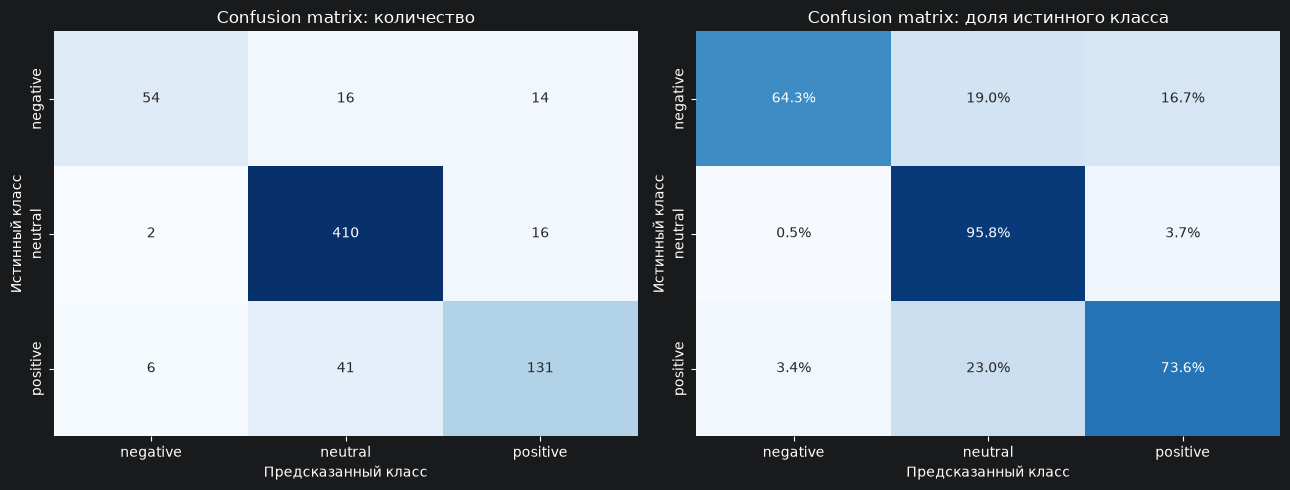

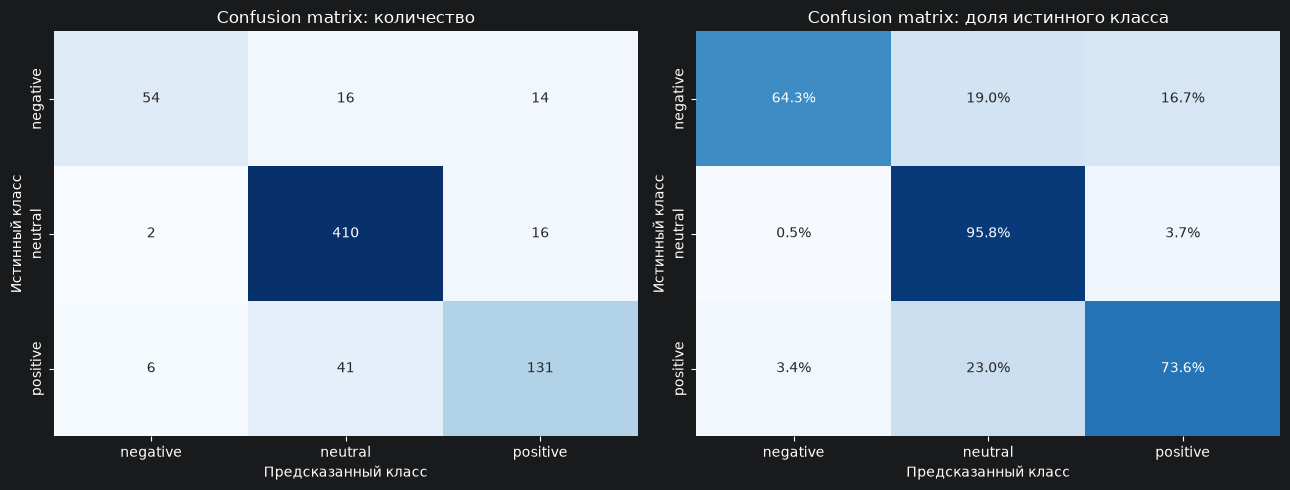

In [10]:
display(confusion_counts.rename_axis('Истинный класс').rename_axis('Предсказанный класс', axis=1))
figure = plot_confusion_matrices(confusion_counts, confusion_normalized)
display(figure)

## 7. Направления ошибок и реальные примеры

Общее число ошибок недостаточно информативно: важно знать направление путаницы. Ниже ошибки сгруппированы как `истинный класс → предсказанный класс`.

In [11]:
transitions = pd.DataFrame(summary['error_transitions'])
transitions['Ошибка'] = transitions['actual'] + ' → ' + transitions['predicted']
display(transitions[['Ошибка', 'count']].rename(columns={'count': 'Количество'}))

,Ошибка,Количество
0,positive → neutral,41
1,negative → neutral,16
2,neutral → positive,16
3,negative → positive,14
4,positive → negative,6
5,neutral → negative,2


LinearSVC для каждого класса возвращает decision score. Разность двух наибольших score называется здесь **decision margin**: малый margin означает, что два класса оказались близко к границе решения. Это не вероятность — значение `0.8` нельзя интерпретировать как 80% уверенности. Для каждого направления покажем три наиболее пограничные ошибки и одну ошибку с наибольшим margin.

In [12]:
errors = predictions.loc[~predictions['correct']].copy()
for (actual, predicted), group in errors.groupby(['actual', 'predicted']):
    ordered = group.sort_values('decision_margin')
    selected = pd.concat([ordered.head(3), ordered.tail(1)]).drop_duplicates('source_index')
    display(Markdown(f'### `{actual} → {predicted}` — {len(group)} ошибок'))
    display(selected[['text', 'decision_margin', 'runner_up_label']].style.format({'decision_margin': '{:.4f}'}))

### `negative → neutral` — 16 ошибок

,text,decision_margin,runner_up_label
212,Rivals say Qualcomm has fewer patents on 3G phones than on earlier versions and should lower its rates .,0.0889,negative
80,Finnlines estimated in its annual general meeting that 2008 will be financially a tough year due to large investments .,0.1264,negative
566,Finnish developer and manufacturer of mobile phone chargers Salcomp Plc OMX Helsinki : SAL1V on Wednesday 19 November lowered its full-year net sales estimate .,0.1422,negative
109,"Many of the commercial vessels had got stuck in the narrow Bay of Bothnia , where the ice is thicker , and around the Aaland islands .",2.2508,negative


### `negative → positive` — 14 ошибок

,text,decision_margin,runner_up_label
366,"According to Scanfil , demand for telecommunications network products has fluctuated significantly in the third quarter of 2006 , and the situation is expected to remain unstable for the rest of the year .",0.0037,negative
544,"Dealers said the share was largely hit by investor disappointment about a refining margin of just 9.48 usd per barrel for the quarter and the performance of its shipping unit , which saw EBIT drop to 5 mln eur from 20 mln eur a year amid a fall in volumes and tanker rates .",0.0173,negative
445,"Belarus OAO Lidskoe Pivo brewery , based in the Grodno Region , reported a 1.1 % decrease in output to 1.045 million decaliters in January-March 2010 , a representative in the administration of the company told .",0.0349,neutral
128,Cash flow from operations in January-December 2008 was a negative EUR 18.1 mn compared to EUR 39.0 mn in the corresponding period in 2007 .,0.6241,negative


### `neutral → negative` — 2 ошибок

...

,text,decision_margin,runner_up_label
217,"AGJ recorded EUR 43 mln sales in 2006 , most of which was generated by exports to customers in Western Europe , the statement said .",0.0172,neutral
422,EUR 152.4 mn of this was net interest income .,0.1519,neutral
385,"Of this , EUR 38.8 mn was net interest income .",0.1858,neutral
598,The increase range will vary up to 10 % .,2.6414,neutral


### `positive → negative` — 6 ошибок

,text,decision_margin,runner_up_label
282,"ADP News - Feb 25 , 2009 - Finnish printed circuit board PCB maker Aspocomp Group Oyj HEL : ACG1V said today it swung to a net profit of EUR 300,000 USD 385,000 for 2008 versus a net loss of EUR 65.3 million",0.0406,positive
169,"In Middle East & North Africa , Tecnotree has grown considerably in the recent years .",0.0541,positive
617,Finnish silicon wafers manufacturer Okmetic Oyj said it swung to a net profit of 4.9 mln euro $ 6.3 mln in the first nine months of 2006 from a net loss of 1.8 mln euro $ 2.3 mln a year earlier .,0.0877,positive
79,Unit costs for flight operations fell by 6.4 percent .,2.3337,positive


### `positive → neutral` — 41 ошибок

,text,decision_margin,runner_up_label
213,The main strength of the cooperation project lies in merging the know-how of two large companies .,0.0242,positive
409,"Fiskars , a 360-year-old global business best known for its orange-handled scissors , expects to derive synergies of EUR5 million a year by consolidating certain parts of the housewares division where the two compete .",0.0627,positive
394,Sports equipment sales also progressed well owing to the prolonged winter season .,0.1081,positive
184,The company is well positioned in Brazil and Uruguay .,2.4087,positive


## 8. Длина текста и близость к границе

Проверим две простые гипотезы: становятся ли длинные фразы сложнее и действительно ли ошибки расположены ближе к границе LinearSVC. Эти описательные статистики не доказывают причинность, но помогают сформулировать дальнейшие эксперименты.

In [13]:
comparison = pd.DataFrame(summary['correct_vs_error']).T
display(comparison.style.format({
    'rows': '{:.0f}',
    'word_count_mean': '{:.2f}',
    'word_count_median': '{:.2f}',
    'margin_mean': '{:.4f}',
    'margin_median': '{:.4f}',
}))

,rows,word_count_mean,word_count_median,margin_mean,margin_median
correct,595,22.19,21.00,1.2873,1.2745
error,95,24.55,24.00,0.6057,0.4212


## 9. Основные failure cases

Ручной просмотр примеров показывает несколько повторяющихся причин:

1. **Косвенный положительный смысл.** Синергия, укрепление сотрудничества или благоприятный сезон описаны как факты и часто превращаются в `positive → neutral`.
2. **Несколько сигналов в одном предложении.** Рост одного показателя может соседствовать с падением другого. Мешок слов суммирует конфликтующую лексику, не понимая структуру фразы.
3. **Сравнения требуют контекста.** Формулировки `rose from a loss to a profit` или `decreased from ... to ...` зависят от порядка и связи чисел. Unigram TF-IDF эту связь теряет.
4. **Число не равно тональности.** Выручка или процент без базы сравнения обычно нейтральны, даже если отдельные токены встречались в положительных примерах.
5. **Пограничная разметка.** Граница между нейтральным сообщением и слабым ожиданием роста или падения частично субъективна. Без независимого разметчика такие случаи нельзя объявлять ошибками датасета.
6. **Ограниченность словаря.** Редкие выражения, имена компаний и контекст за пределами одного предложения представлены слабо.

## 10. Что улучшать дальше

Следующие идеи нельзя проверять повторным подбором на этом test set — для них понадобится новая validation-схема:

- проверить контекстные sentence embeddings или transformer, способные учитывать порядок и композицию;
- повторно исследовать n-граммы только внутри cross-validation на train;
- провести независимый аудит спорных `neutral`/`positive` и `neutral`/`negative` примеров;
- если inference потребует confidence, отдельно откалибровать модель или выбрать классификатор с вероятностями;
- анализировать качество на новых данных и отслеживать сдвиг лексики финансовых сообщений.

## 11. Сохранение отчётов

Сохраняем визуализацию, абсолютную матрицу, все ошибочные строки и полный JSON summary. CSV с ошибками отсортирован по направлению ошибки и margin, поэтому его удобно просматривать вручную.

In [14]:
artifact_paths = save_error_analysis_artifacts(
    predictions, confusion_counts, confusion_normalized, summary, REPORT_DIR
)
for name, path in artifact_paths.items():
    print(f'{name}: {path.relative_to(PROJECT_ROOT)}')

figure: reports/day05/confusion_matrix.png
confusion_csv: reports/day05/confusion_matrix.csv
errors_csv: reports/day05/error_examples.csv
summary_json: reports/day05/error_analysis.json


## 12. Выводы

- Модель воспроизводимо получает **macro F1 = 0.8096** и ошибается в **95 из 690** test-примеров.
- Самая частая проблема — **`positive → neutral` (41 пример)**: положительный смысл нередко выражен косвенно.
- Отрицательный класс имеет самый низкий recall; часть негативных фраз уходит как в `neutral`, так и в `positive`.
- Ошибки в среднем ближе к границе решений и немного длиннее правильных примеров.
- Главные ограничения связаны не только с дисбалансом, но и с unigram-представлением, которое не моделирует порядок слов и контекст.
- Test set выполнил диагностическую роль. Предложения по улучшению зафиксированы, но качество после них должно измеряться на новой честной схеме оценки.